In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from itertools import combinations

# Make src importable
sys.path.append("..")
from src import config
from src.preprocessing import normalize

# Plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

np.random.seed(config.RANDOM_SEED)

print(" Setup complete")

 Setup complete


In [2]:
import json

with open(config.TOMATO_SPLITS_FILE, "rb") as f:
    splits = pickle.load(f)

X_test = splits["X_test"]
y_test = splits["y_test"]
TOMATO_CLASSES = splits["classes"]
TOMATO_CLASS_DISPLAY = splits["class_display"]
display_names = [TOMATO_CLASS_DISPLAY[c] for c in TOMATO_CLASSES]

model = tf.keras.models.load_model(config.TOMATO_MODEL_BEST)

# 3. Load metadata and CROSS-CHECK
with open(config.TOMATO_MODEL_META) as f:
    meta = json.load(f)

print(" Model metadata verification:")
print(f"   Classes: {meta['classes']}")
print(f"   Image size: {meta['img_size']}")
print(f"   Input range: {meta['expected_input_range']}")

# ── Safety checks (catch mismatched model/data before wasting 5 min) ──
assert meta["classes"] == list(TOMATO_CLASSES), (
    f" Model expects classes {meta['classes']}\n"
    f"   but data has {TOMATO_CLASSES}"
)
assert meta["img_size"] == X_test.shape[1], (
    f" Model expects {meta['img_size']}px, got {X_test.shape[1]}px"
)
assert meta["num_classes"] == model.output_shape[-1], (
    f" Metadata says {meta['num_classes']} classes, "
    f"but model outputs {model.output_shape[-1]}"
)

print(" Metadata checks passed — model and data are compatible")

 Model metadata verification:
   Classes: ['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Tomato_healthy']
   Image size: 96
   Input range: [0, 255]
 Metadata checks passed — model and data are compatible


In [3]:
X_test_f = X_test.astype("float32")   # just cast, don't scale

y_proba = model.predict(X_test_f, batch_size=32, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

test_acc = np.mean(y_pred == y_test)
print(f"\n Test accuracy: {test_acc:.4f}")
print(f" Test size: {len(y_test)}")
print("\n" + classification_report(y_test, y_pred,
                                    target_names=display_names,
                                    digits=4, zero_division=0))


 Test accuracy: 0.9528
 Test size: 995

                precision    recall  f1-score   support

  Early Blight     0.9058    0.8333    0.8681       150
   Late Blight     0.9450    0.9582    0.9516       287
Bacterial Spot     0.9717    0.9687    0.9702       319
       Healthy     0.9637    1.0000    0.9815       239

      accuracy                         0.9528       995
     macro avg     0.9466    0.9400    0.9428       995
  weighted avg     0.9521    0.9528    0.9521       995



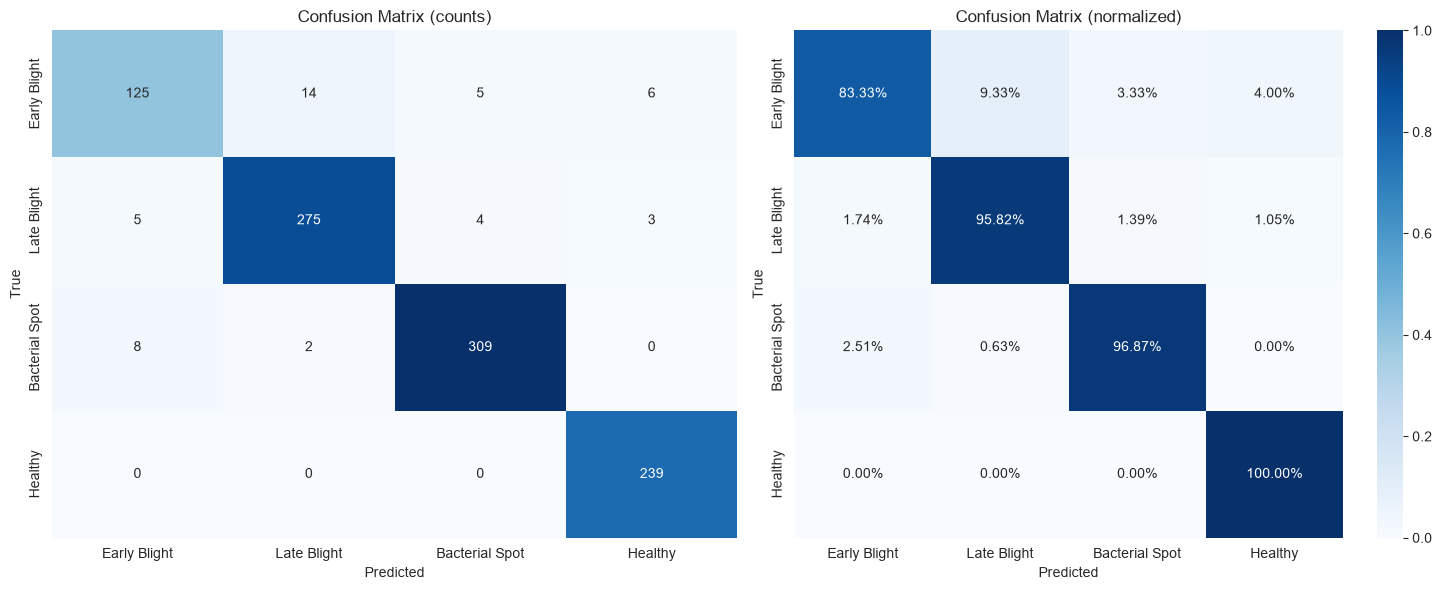

In [4]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=display_names, yticklabels=display_names,
            ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=display_names, yticklabels=display_names,
            ax=axes[1], vmax=1.0)
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{config.DOCS_DIR}/tomato_error_confusion.png",
            dpi=120, bbox_inches="tight")
plt.show()

 Misclassified: 47 / 995 (4.7%)


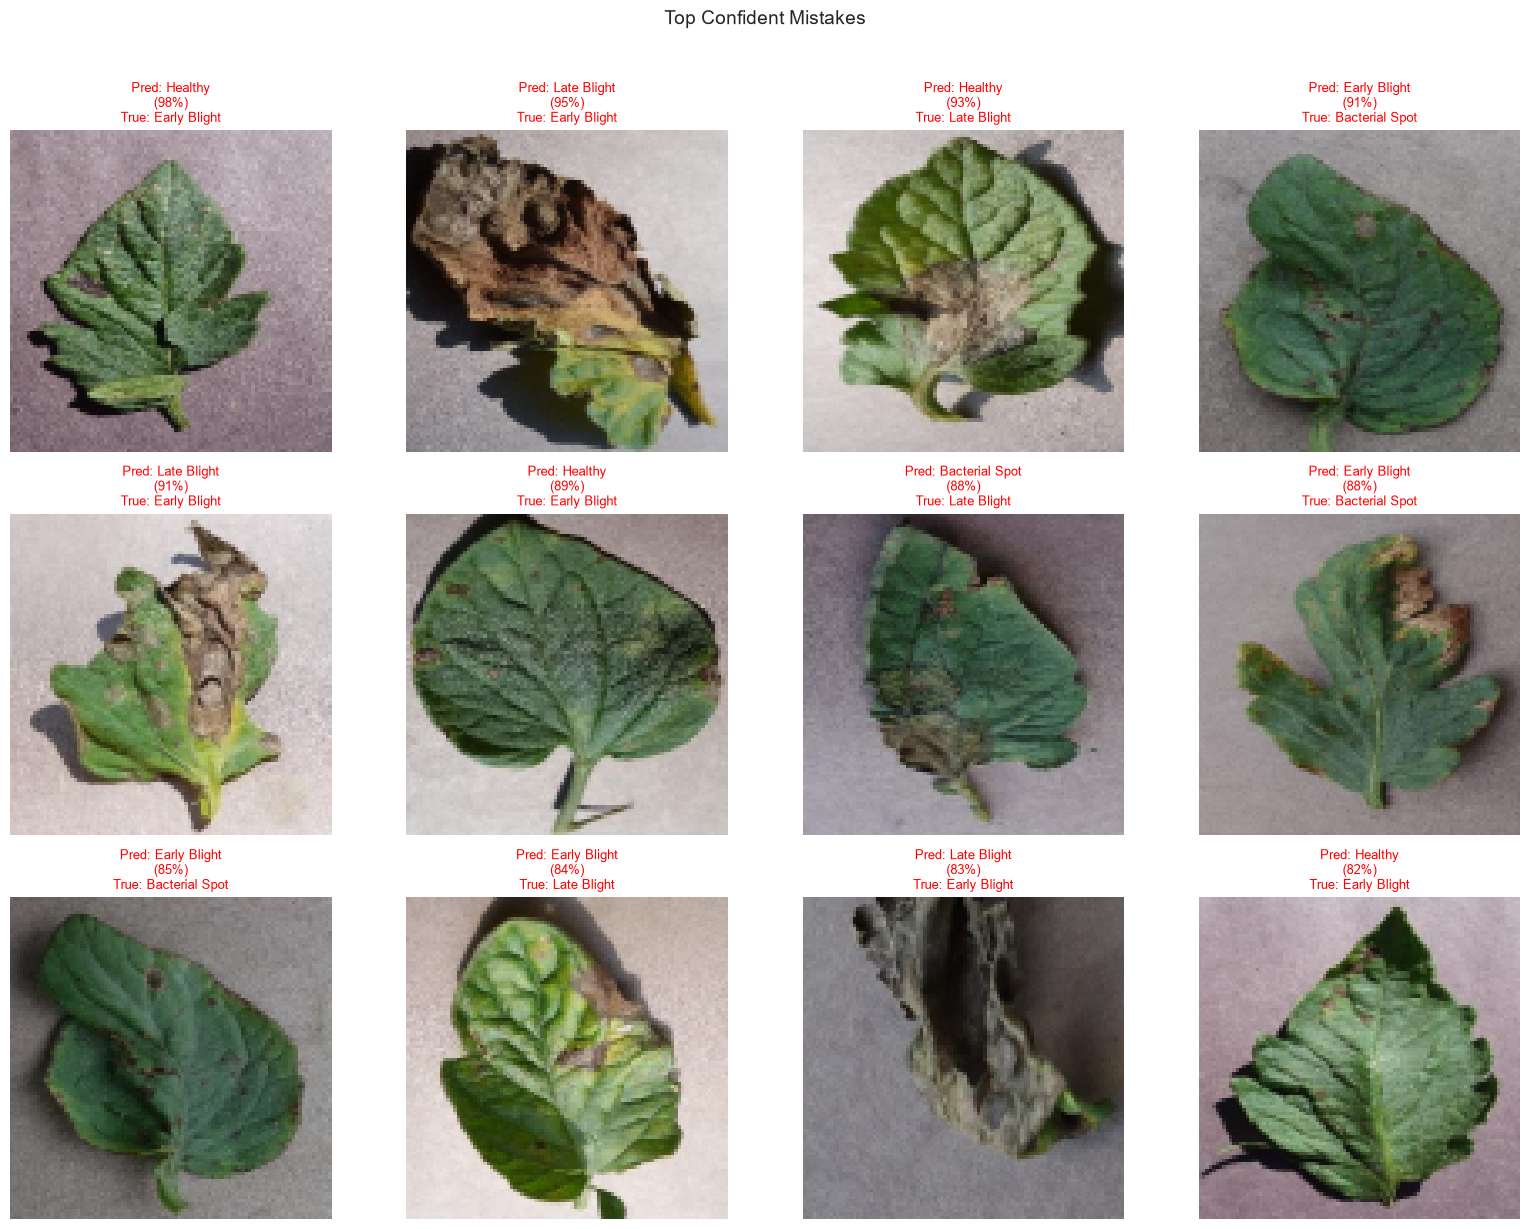

In [5]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f" Misclassified: {len(wrong_idx)} / {len(y_test)} "
      f"({len(wrong_idx)/len(y_test)*100:.1f}%)")

if len(wrong_idx) > 0:
    wrong_conf = y_proba[wrong_idx, y_pred[wrong_idx]]
    sorted_idx = wrong_idx[np.argsort(-wrong_conf)] 

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    for i, idx in enumerate(sorted_idx[:12]):
        axes[i].imshow(X_test[idx])
        axes[i].set_title(
            f"Pred: {display_names[y_pred[idx]]}\n"
            f"({y_proba[idx, y_pred[idx]]*100:.0f}%)\n"
            f"True: {display_names[y_test[idx]]}",
            fontsize=9, color="red"
        )
        axes[i].axis("off")
    plt.suptitle("Top Confident Mistakes", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{config.DOCS_DIR}/tomato_misclassified_v2.png",
                dpi=120, bbox_inches="tight")
    plt.show()

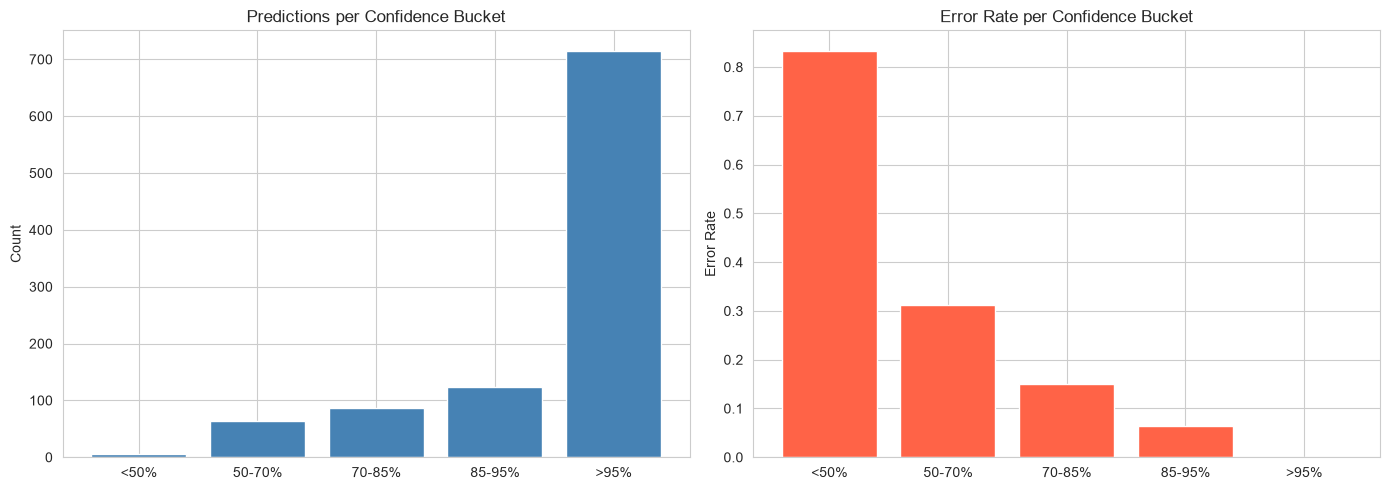

   bucket  count  accuracy  error_rate
0    <50%      6  0.166667    0.833333
1  50-70%     64  0.687500    0.312500
2  70-85%     87  0.850575    0.149425
3  85-95%    123  0.934959    0.065041
4    >95%    715  0.998601    0.001399


In [7]:
max_proba = y_proba.max(axis=1)
correct = (y_pred == y_test)

bins = [0.0, 0.5, 0.7, 0.85, 0.95, 1.01]
labels = ["<50%", "50-70%", "70-85%", "85-95%", ">95%"]

df_conf = pd.DataFrame({
    "confidence": max_proba,
    "correct": correct,
    "bucket": pd.cut(max_proba, bins=bins, labels=labels, right=False),
})

summary = df_conf.groupby("bucket", observed=True).agg(
    count=("correct", "size"),
    accuracy=("correct", "mean"),
).reset_index()
summary["error_rate"] = 1 - summary["accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(summary["bucket"].astype(str), summary["count"], color="steelblue")
axes[0].set_title("Predictions per Confidence Bucket")
axes[0].set_ylabel("Count")

axes[1].bar(summary["bucket"].astype(str), summary["error_rate"], color="tomato")
axes[1].set_title("Error Rate per Confidence Bucket")
axes[1].set_ylabel("Error Rate")

plt.tight_layout()
plt.savefig(f"{config.DOCS_DIR}/tomato_confidence_buckets_v2.png", dpi=120)
plt.show()
print(summary)

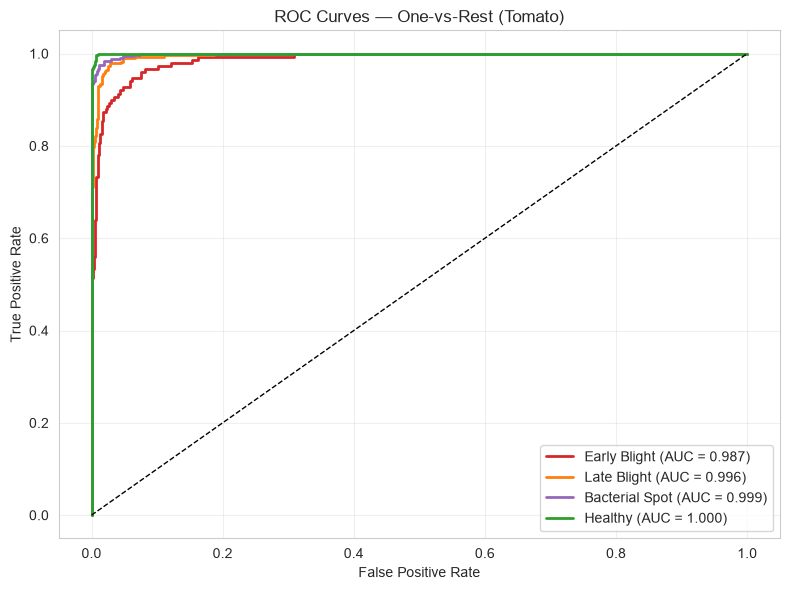

In [8]:
y_test_bin = label_binarize(y_test, classes=list(range(len(TOMATO_CLASSES))))

plt.figure(figsize=(8, 6))
colors = ["tab:red", "tab:orange", "tab:purple", "tab:green"]

for i, (cls, color) in enumerate(zip(display_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest (Tomato)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{config.DOCS_DIR}/tomato_roc_curves_v2.png", dpi=120)
plt.show()

In [9]:
summary_data = {
    "overall_accuracy": float(test_acc),
    "total_test_samples": int(len(y_test)),
    "misclassified": int(len(wrong_idx)),
    "error_rate": float(len(wrong_idx) / len(y_test)),
    "per_class": {},
}
for i, cls in enumerate(display_names):
    mask = y_test == i
    summary_data["per_class"][cls] = {
        "precision": float(cm[i, i] / cm[:, i].sum()) if cm[:, i].sum() else 0,
        "recall":    float(cm[i, i] / cm[i, :].sum()) if cm[i, :].sum() else 0,
        "support":   int(mask.sum()),
    }

import json
with open(f"{config.DOCS_DIR}/tomato_error_summary_v2.json", "w") as f:
    json.dump(summary_data, f, indent=2)
print(f" Saved: {config.DOCS_DIR}/tomato_error_summary_v2.json")

 Saved: c:\Users\HP\Downloads\Plant Dieases Classification Model\docs/tomato_error_summary_v2.json
